In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "Data"
    / "processed"
    / "imd_temperature_2010_2025.parquet"
)

print(DATA_PATH)
print(DATA_PATH.exists())

c:\Users\Qudsiya Siddique\Desktop\Climat\Data\processed\imd_temperature_2010_2025.parquet
True


In [3]:
df = pd.read_parquet(DATA_PATH)

df.head()

,date,latitude,longitude,max_temperature
0,2010-01-01,8.5,73.5,32.869999
1,2010-01-01,8.5,76.5,31.040001
2,2010-01-01,8.5,77.5,32.040001
3,2010-01-01,8.5,78.5,31.110001
4,2010-01-01,9.5,76.5,31.270000


In [4]:
print("Shape:", df.shape)
print("Date range:", df["date"].min(), "→", df["date"].max())
print("Unique dates:", df["date"].nunique())
print("Unique locations:", df[["latitude", "longitude"]].drop_duplicates().shape[0])

Shape: (2074620, 4)
Date range: 2010-01-01 00:00:00 → 2025-12-31 00:00:00
Unique dates: 5844
Unique locations: 355


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2074620 entries, 0 to 2074619
Data columns (total 4 columns):
 #   Column           Dtype         
---  ------           -----         
 0   date             datetime64[us]
 1   latitude         float64       
 2   longitude        float64       
 3   max_temperature  float32       
dtypes: datetime64[us](1), float32(1), float64(2)
memory usage: 55.4 MB


In [6]:
missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"]
    / len(df)
    * 100
)

missing_summary

,missing_count,missing_percentage
date,0,0.000000
latitude,0,0.000000
longitude,0,0.000000
max_temperature,4244,0.204568


In [7]:
df["max_temperature"].describe()
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

print(
    "Duplicate date-location combinations:",
    df.duplicated(
        subset=["date", "latitude", "longitude"]
    ).sum()
)

Duplicate rows: 0
Duplicate date-location combinations: 0


In [8]:
missing_count = df["max_temperature"].isna().sum()
total_count = len(df)

print(f"Missing values: {missing_count:,}")
print(f"Total observations: {total_count:,}")
print(f"Missing percentage: {(missing_count / total_count) * 100:.4f}%") 

Missing values: 4,244
Total observations: 2,074,620
Missing percentage: 0.2046%


In [9]:
missing_by_year = (
    df.assign(year=df["date"].dt.year)
      .groupby("year")["max_temperature"]
      .agg(
          total="size",
          missing="count"
      )
)

missing_by_year["missing"] = (
    missing_by_year["total"] - missing_by_year["missing"]
)

missing_by_year["missing_percentage"] = (
    missing_by_year["missing"]
    / missing_by_year["total"]
    * 100
)

missing_by_year

,total,missing,missing_percentage
year,,,
2010,129575,1024,0.790276
2011,129575,385,0.297125
2012,129930,183,0.140845
2013,129575,474,0.365811
2014,129575,78,0.060197
2015,129575,215,0.165927
2016,129930,109,0.083891
2017,129575,95,0.073317
2018,129575,621,0.479259


In [10]:
missing_by_location = (
    df.groupby(["latitude", "longitude"])["max_temperature"]
      .agg(
          total="size",
          missing=lambda x: x.isna().sum()
      )
      .reset_index()
)

missing_by_location["missing_percentage"] = (
    missing_by_location["missing"]
    / missing_by_location["total"]
    * 100
)

missing_by_location.sort_values(
    "missing",
    ascending=False
).head(20)

,latitude,longitude,total,missing,missing_percentage
309,29.5,96.5,5844,865,14.801506
308,29.5,95.5,5844,865,14.801506
350,35.5,79.5,5844,605,10.352498
352,36.5,73.5,5844,444,7.597536
351,36.5,72.5,5844,444,7.597536
353,36.5,74.5,5844,444,7.597536
349,35.5,78.5,5844,98,1.676934
354,36.5,75.5,5844,98,1.676934
307,29.5,94.5,5844,56,0.958248
297,28.5,96.5,5844,52,0.889802


In [11]:
missing_by_month = (
    df.assign(month=df["date"].dt.month)
      .groupby("month")["max_temperature"]
      .agg(
          total="size",
          missing=lambda x: x.isna().sum()
      )
)

missing_by_month["missing_percentage"] = (
    missing_by_month["missing"]
    / missing_by_month["total"]
    * 100
)

missing_by_month

,total,missing,missing_percentage
month,,,
1,176080,369,0.209564
2,160460,242,0.150816
3,176080,498,0.282826
4,170400,289,0.169601
5,176080,337,0.191390
6,170400,273,0.160211
7,176080,459,0.260677
8,176080,267,0.151636
9,170400,269,0.157864


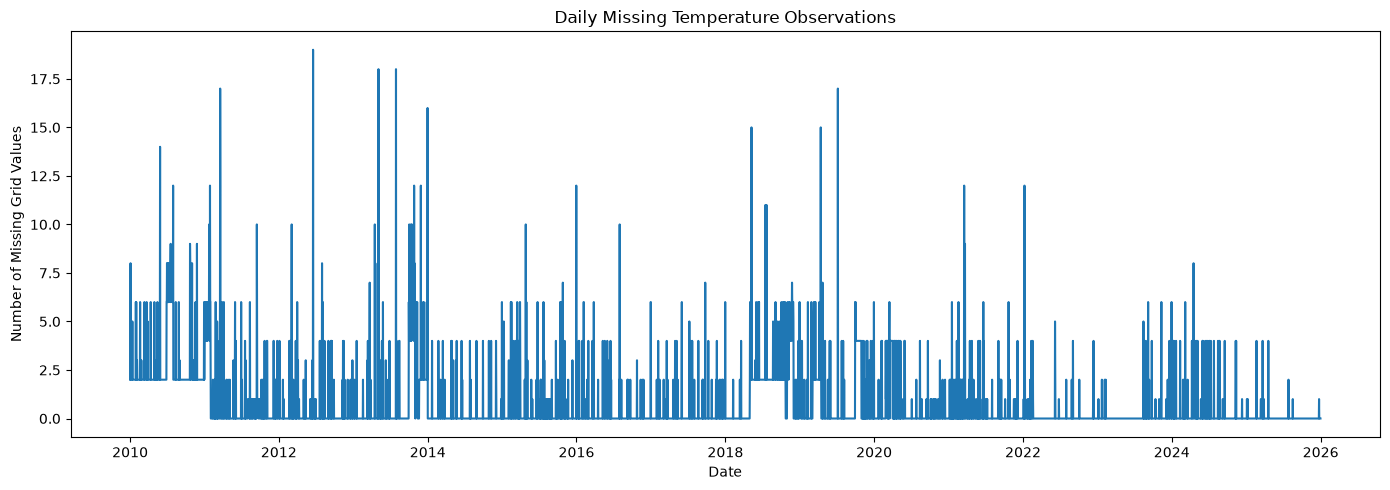

In [12]:
daily_missing = (
    df.groupby("date")["max_temperature"]
      .apply(lambda x: x.isna().sum())
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_missing.index,
    daily_missing.values
)

plt.xlabel("Date")
plt.ylabel("Number of Missing Grid Values")
plt.title("Daily Missing Temperature Observations")

plt.tight_layout()
plt.show()

In [13]:
missing_df = (
    df[df["max_temperature"].isna()]
    [["date", "latitude", "longitude"]]
    .sort_values(["latitude", "longitude", "date"])
    .copy()
)

missing_df["date_diff"] = (
    missing_df
    .groupby(["latitude", "longitude"])["date"]
    .diff()
    .dt.days
)

missing_df.head()

,date,latitude,longitude,date_diff
1611796,2022-06-07,20.5,70.5,NaN
1611813,2022-06-07,21.5,69.5,NaN
1611833,2022-06-07,22.5,69.5,NaN
432898,2013-05-04,22.5,92.5,NaN
1611854,2022-06-07,23.5,68.5,NaN


Temporal Analysis

In [14]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_year"] = df["date"].dt.dayofyear
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Pre-Monsoon"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"


df["season"] = df["month"].apply(get_season)

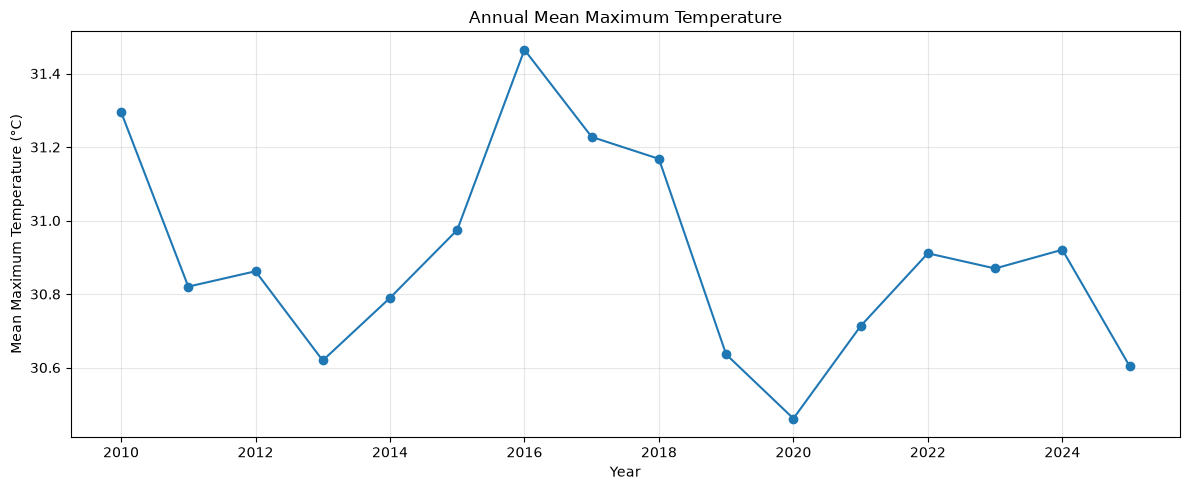

In [15]:
yearly_temp = (
    df.groupby("year")["max_temperature"]
      .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    yearly_temp.index,
    yearly_temp.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Mean Maximum Temperature (°C)")
plt.title("Annual Mean Maximum Temperature")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

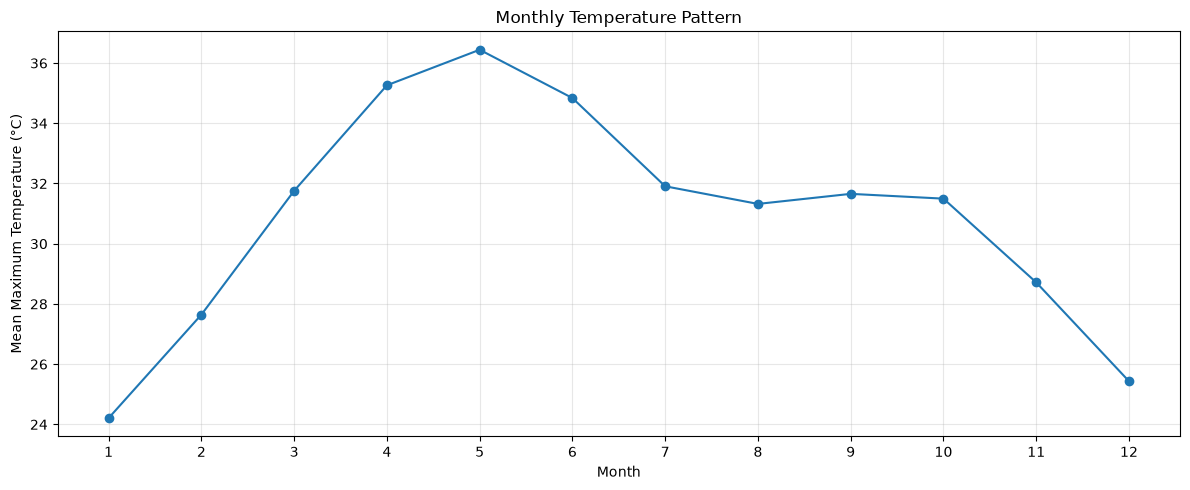

In [16]:
monthly_temp = (
    df.groupby("month")["max_temperature"]
      .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_temp.index,
    monthly_temp.values,
    marker="o"
)

plt.xticks(range(1, 13))

plt.xlabel("Month")
plt.ylabel("Mean Maximum Temperature (°C)")
plt.title("Monthly Temperature Pattern")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
seasonal_temp = (
    df.groupby("season")["max_temperature"]
      .agg(["mean", "median", "std", "min", "max"])
)

seasonal_temp

,mean,median,std,min,max
season,,,,,
Monsoon,32.417641,32.153385,3.584395,15.402680,47.792606
Post-Monsoon,30.128588,30.774635,3.974349,4.667158,40.117455
Pre-Monsoon,34.479687,35.330200,5.733964,4.173010,48.770992
Winter,25.705462,26.850000,5.916241,2.015030,39.115086


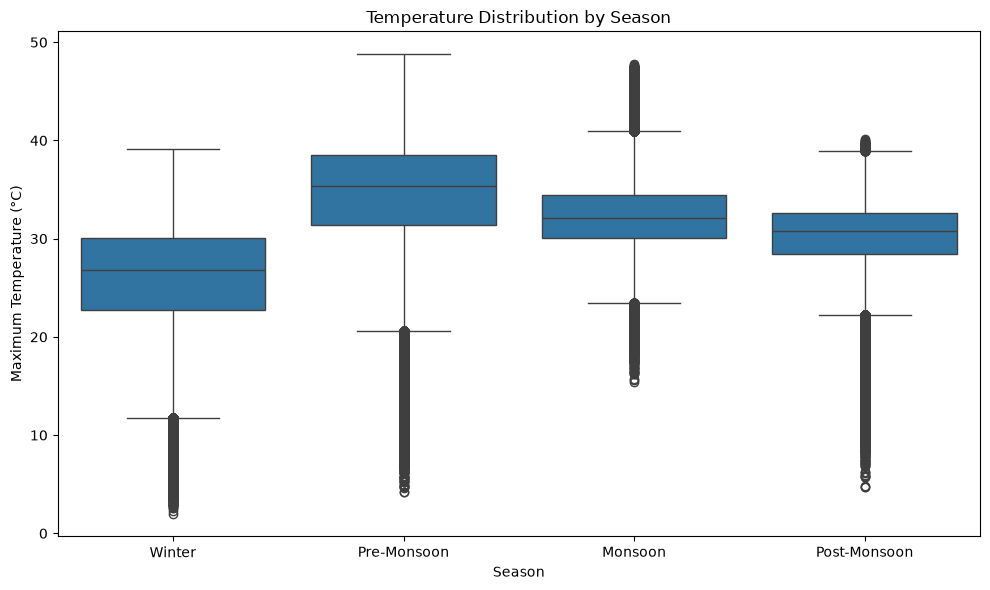

In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="season",
    y="max_temperature",
    order=[
        "Winter",
        "Pre-Monsoon",
        "Monsoon",
        "Post-Monsoon"
    ]
)

plt.xlabel("Season")
plt.ylabel("Maximum Temperature (°C)")
plt.title("Temperature Distribution by Season")

plt.tight_layout()
plt.show()

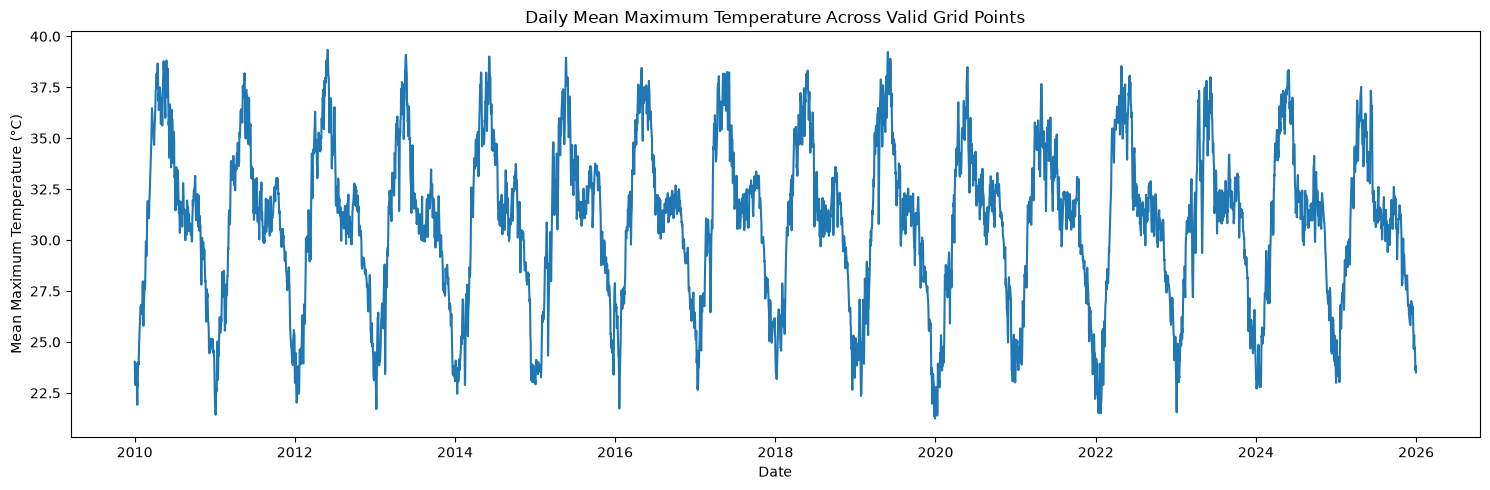

In [19]:
daily_temp = (
    df.groupby("date")["max_temperature"]
      .mean()
)

plt.figure(figsize=(15, 5))

plt.plot(
    daily_temp.index,
    daily_temp.values
)

plt.xlabel("Date")
plt.ylabel("Mean Maximum Temperature (°C)")
plt.title("Daily Mean Maximum Temperature Across Valid Grid Points")

plt.tight_layout()
plt.show()

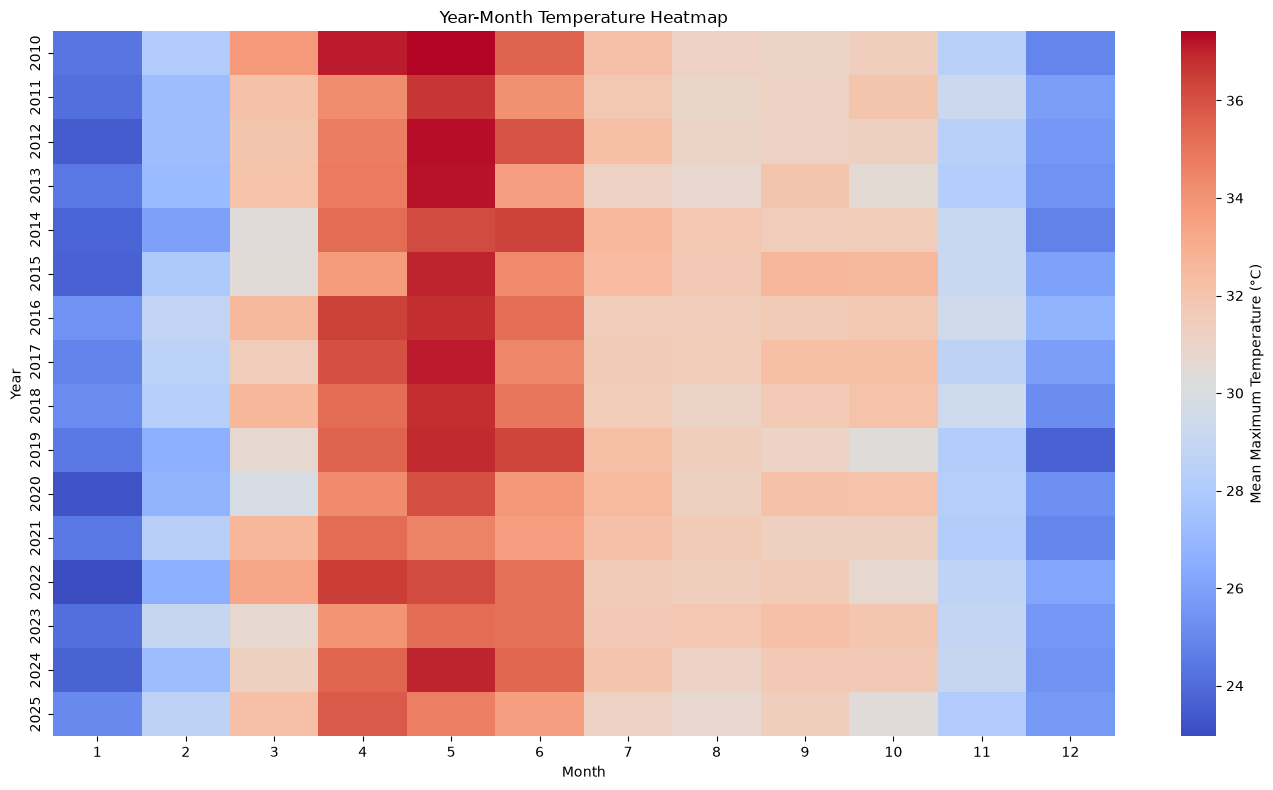

In [20]:
year_month_temp = (
    df.groupby(["year", "month"])["max_temperature"]
      .mean()
      .reset_index()
)

pivot_year_month = year_month_temp.pivot(
    index="year",
    columns="month",
    values="max_temperature"
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    pivot_year_month,
    annot=False,
    cmap="coolwarm",
    cbar_kws={
        "label": "Mean Maximum Temperature (°C)"
    }
)

plt.xlabel("Month")
plt.ylabel("Year")
plt.title("Year-Month Temperature Heatmap")

plt.tight_layout()
plt.show()

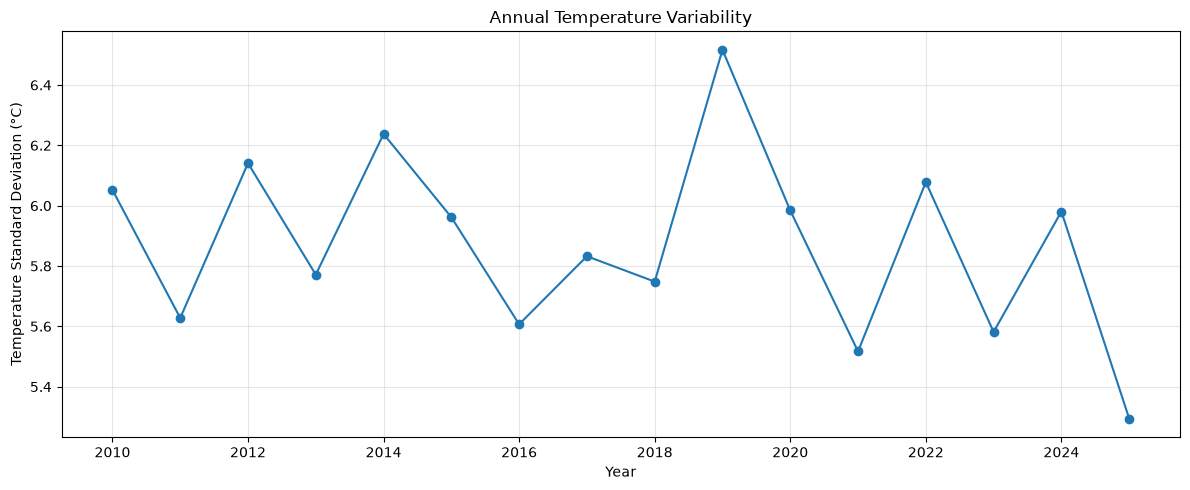

In [21]:
yearly_stats = (
    df.groupby("year")["max_temperature"]
      .agg(
          mean="mean",
          median="median",
          std="std",
          min="min",
          max="max"
      )
)

yearly_stats
plt.figure(figsize=(12, 5))

plt.plot(
    yearly_stats.index,
    yearly_stats["std"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Temperature Standard Deviation (°C)")
plt.title("Annual Temperature Variability")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
hottest_days = (
    daily_temp
    .sort_values(ascending=False)
    .head(20)
)

hottest_days
hottest_observations = (
    df.nlargest(
        20,
        "max_temperature"
    )[
        [
            "date",
            "latitude",
            "longitude",
            "max_temperature"
        ]
    ]
)

hottest_observations

,date,latitude,longitude,max_temperature
827429,2016-05-19,28.5,70.5,48.770992
827406,2016-05-19,27.5,72.5,48.464844
827430,2016-05-19,28.5,71.5,48.421509
827431,2016-05-19,28.5,72.5,48.215137
1867888,2024-05-28,26.5,76.5,48.094631
1867598,2024-05-27,29.5,72.5,48.006294
1867580,2024-05-27,28.5,71.5,48.005222
827405,2016-05-19,27.5,71.5,47.979759
827407,2016-05-19,27.5,73.5,47.977516
827432,2016-05-19,28.5,73.5,47.957943


In [23]:
thresholds = [40, 42, 45]

extreme_counts = {}

for threshold in thresholds:
    extreme_counts[threshold] = (
        df["max_temperature"] >= threshold
    ).sum()

extreme_counts

{40: np.int64(105160), 42: np.int64(40427), 45: np.int64(3360)}

In [24]:
extreme_by_year = (
    df.assign(
        extreme_40=df["max_temperature"] >= 40,
        extreme_42=df["max_temperature"] >= 42,
        extreme_45=df["max_temperature"] >= 45
    )
    .groupby("year")[
        ["extreme_40", "extreme_42", "extreme_45"]
    ]
    .sum()
)

extreme_by_year

,extreme_40,extreme_42,extreme_45
year,,,
2010,10686,4951,416
2011,4675,1477,67
2012,7398,2946,169
2013,5732,2488,213
2014,6401,2318,349
2015,6294,2629,176
2016,8377,3377,256
2017,8118,2950,105
2018,7071,2937,168


Spatial Analysis

In [25]:
# Average temperature for each spatial grid point

spatial_mean = (
    df.groupby(["latitude", "longitude"])["max_temperature"]
      .agg(
          mean_temperature="mean",
          min_temperature="min",
          max_temperature="max",
          std_temperature="std",
          observations="count"
      )
      .reset_index()
)

spatial_mean.head()

,latitude,longitude,mean_temperature,min_temperature,max_temperature,std_temperature,observations
0,8.5,73.5,32.243492,26.566252,37.075432,1.671660,5844
1,8.5,76.5,31.402248,25.816338,35.948830,1.508233,5844
2,8.5,77.5,33.164513,26.532669,37.726574,1.615201,5844
3,8.5,78.5,33.359852,25.496593,37.965717,1.942006,5844
4,9.5,76.5,31.444613,25.582672,36.576340,1.780180,5844


In [26]:
print("Number of spatial locations:", len(spatial_mean))

Number of spatial locations: 355


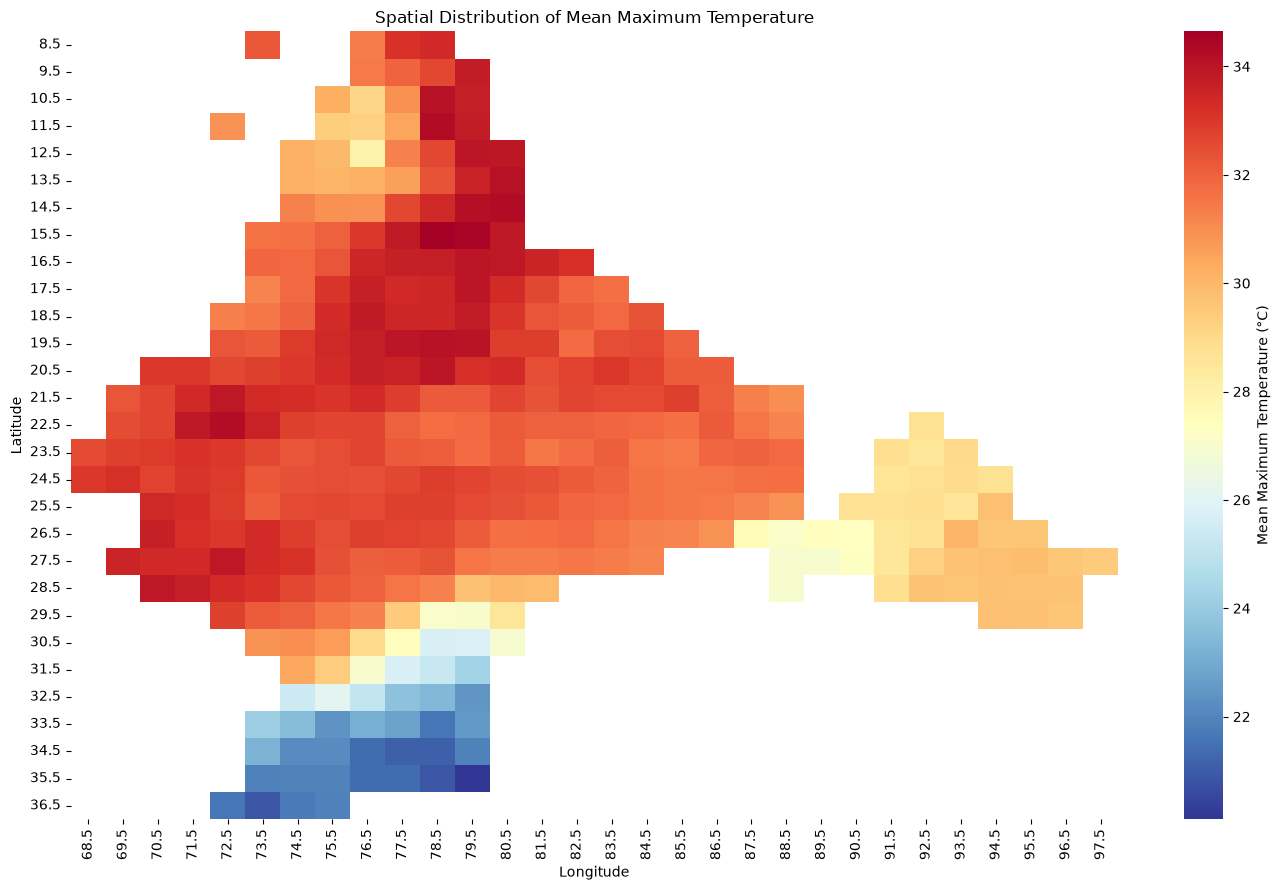

In [27]:
spatial_pivot = spatial_mean.pivot(
    index="latitude",
    columns="longitude",
    values="mean_temperature"
)

plt.figure(figsize=(14, 9))

sns.heatmap(
    spatial_pivot,
    cmap="RdYlBu_r",
    annot=False,
    cbar_kws={"label": "Mean Maximum Temperature (°C)"}
)

plt.title("Spatial Distribution of Mean Maximum Temperature")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

In [28]:
hottest_locations = (
    spatial_mean
    .sort_values("mean_temperature", ascending=False)
    .head(15)
)

hottest_locations
hottest_locations[
    [
        "latitude",
        "longitude",
        "mean_temperature",
        "min_temperature",
        "max_temperature",
        "std_temperature"
    ]
]

,latitude,longitude,mean_temperature,min_temperature,max_temperature,std_temperature
45,15.5,78.5,34.647873,23.628590,44.406818,3.483652
46,15.5,79.5,34.527786,23.114159,44.430000,3.332206
17,11.5,78.5,34.298355,24.293291,41.887932,2.976419
39,14.5,80.5,34.268742,24.219999,44.263962,3.249206
136,22.5,72.5,34.219879,21.383930,43.914318,3.940370
38,14.5,79.5,34.185879,23.870001,43.641224,3.322998
88,19.5,78.5,34.131710,23.212954,46.162251,4.528223
11,10.5,78.5,34.109138,24.235235,40.385456,2.813504
32,13.5,80.5,34.088150,23.549999,43.513519,3.221864
89,19.5,79.5,34.023453,21.910978,46.874161,4.525264


In [29]:
coldest_locations = (
    spatial_mean
    .sort_values("mean_temperature", ascending=True)
    .head(15)
)

coldest_locations[
    [
        "latitude",
        "longitude",
        "mean_temperature",
        "min_temperature",
        "max_temperature",
        "std_temperature"
    ]
]

,latitude,longitude,mean_temperature,min_temperature,max_temperature,std_temperature
350,35.5,79.5,20.102501,2.015030,33.417213,7.345655
349,35.5,78.5,20.877924,2.854094,34.549393,7.303745
352,36.5,73.5,20.893742,2.615234,34.764160,7.712213
342,34.5,78.5,21.083984,3.194150,34.318008,7.204377
341,34.5,77.5,21.109526,3.273033,35.284611,7.301978
347,35.5,76.5,21.364748,3.365392,34.762836,7.286428
348,35.5,77.5,21.371534,3.318336,34.779663,7.284198
340,34.5,76.5,21.403103,3.594705,35.206524,7.308978
351,36.5,72.5,21.592934,3.605593,35.640800,7.511952
335,33.5,78.5,21.624456,4.934227,35.610836,6.463991


In [30]:
highest_variability = (
    spatial_mean
    .sort_values("std_temperature", ascending=False)
    .head(15)
)

highest_variability[
    [
        "latitude",
        "longitude",
        "mean_temperature",
        "std_temperature",
        "min_temperature",
        "max_temperature"
    ]
]

,latitude,longitude,mean_temperature,std_temperature,min_temperature,max_temperature
352,36.5,73.5,20.893742,7.712213,2.615234,34.764160
353,36.5,74.5,21.723835,7.610001,3.587238,36.040581
351,36.5,72.5,21.592934,7.511952,3.605593,35.640800
310,30.5,73.5,30.881657,7.505095,10.180000,46.475685
311,30.5,74.5,30.999180,7.488647,10.450000,46.660000
346,35.5,75.5,21.923786,7.414632,4.251795,35.522644
345,35.5,74.5,21.923080,7.409372,4.292827,35.542801
344,35.5,73.5,21.899576,7.404629,4.339318,35.586628
339,34.5,75.5,22.175159,7.402525,4.419112,36.464729
332,33.5,75.5,22.366344,7.401986,4.394925,36.602692


In [31]:
spatial_extremes = (
    spatial_mean
    .sort_values("max_temperature", ascending=False)
    .head(20)
)

spatial_extremes[
    [
        "latitude",
        "longitude",
        "max_temperature",
        "mean_temperature",
        "std_temperature"
    ]
]

,latitude,longitude,max_temperature,mean_temperature,std_temperature
279,28.5,70.5,48.770992,33.884987,6.356357
256,27.5,72.5,48.464844,33.890278,6.125020
280,28.5,71.5,48.421509,33.731426,6.540110
281,28.5,72.5,48.215137,33.320538,6.711197
233,26.5,76.5,48.094631,32.783314,6.714969
298,29.5,72.5,48.006294,32.776123,7.155519
255,27.5,71.5,47.979759,33.350903,5.875552
257,27.5,73.5,47.977516,33.322338,6.406582
282,28.5,73.5,47.957943,33.154739,6.786882
210,25.5,77.5,47.792606,32.828873,6.443653


In [32]:
extreme_by_location = (
    df.assign(
        extreme_40=df["max_temperature"] > 40
    )
    .groupby(["latitude", "longitude"])["extreme_40"]
    .sum()
    .reset_index(name="days_above_40")
)

extreme_by_location = extreme_by_location.sort_values(
    "days_above_40",
    ascending=False
)

extreme_by_location.head(20)

,latitude,longitude,days_above_40
279,28.5,70.5,975
104,20.5,78.5,970
280,28.5,71.5,970
256,27.5,72.5,947
88,19.5,78.5,940
210,25.5,77.5,926
211,25.5,78.5,921
233,26.5,76.5,918
281,28.5,72.5,911
234,26.5,77.5,910


In [33]:
extreme_by_location = (
    df.assign(
        extreme_40=df["max_temperature"] > 40
    )
    .groupby(["latitude", "longitude"])["extreme_40"]
    .sum()
    .reset_index(name="days_above_40")
)

extreme_by_location = extreme_by_location.sort_values(
    "days_above_40",
    ascending=False
)

extreme_by_location.head(20)

,latitude,longitude,days_above_40
279,28.5,70.5,975
104,20.5,78.5,970
280,28.5,71.5,970
256,27.5,72.5,947
88,19.5,78.5,940
210,25.5,77.5,926
211,25.5,78.5,921
233,26.5,76.5,918
281,28.5,72.5,911
234,26.5,77.5,910


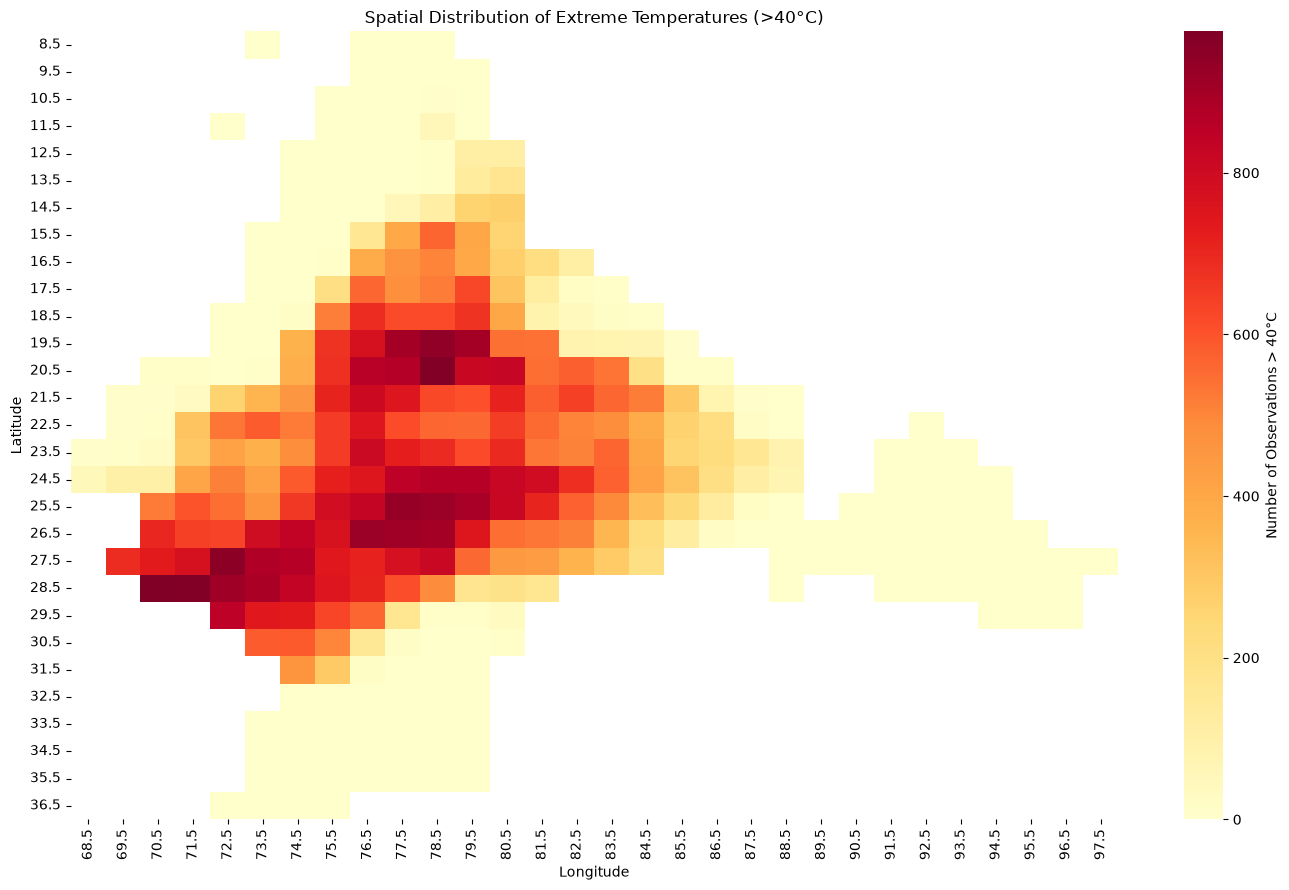

In [34]:
extreme_40 = (
    df.assign(extreme_40=df["max_temperature"] > 40)
      .groupby(["latitude", "longitude"])["extreme_40"]
      .sum()
      .reset_index(name="days_above_40")
)

extreme_pivot = extreme_40.pivot(
    index="latitude",
    columns="longitude",
    values="days_above_40"
)

plt.figure(figsize=(14, 9))

sns.heatmap(
    extreme_pivot,
    cmap="YlOrRd",
    annot=False,
    cbar_kws={"label": "Number of Observations > 40°C"}
)

plt.title("Spatial Distribution of Extreme Temperatures (>40°C)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

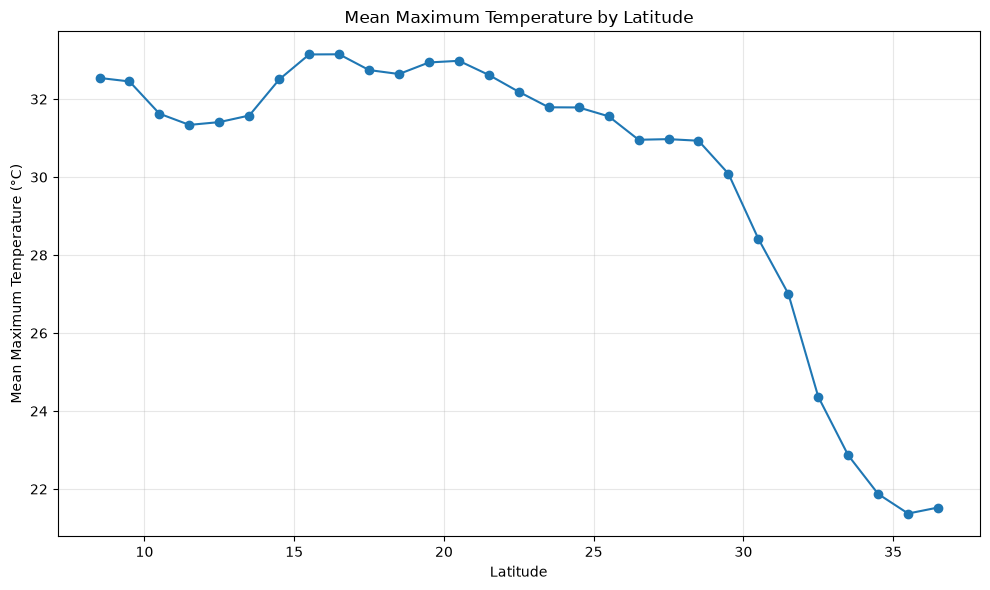

In [35]:
latitude_temperature = (
    df.groupby("latitude")["max_temperature"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    latitude_temperature["latitude"],
    latitude_temperature["max_temperature"],
    marker="o"
)

plt.title("Mean Maximum Temperature by Latitude")
plt.xlabel("Latitude")
plt.ylabel("Mean Maximum Temperature (°C)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

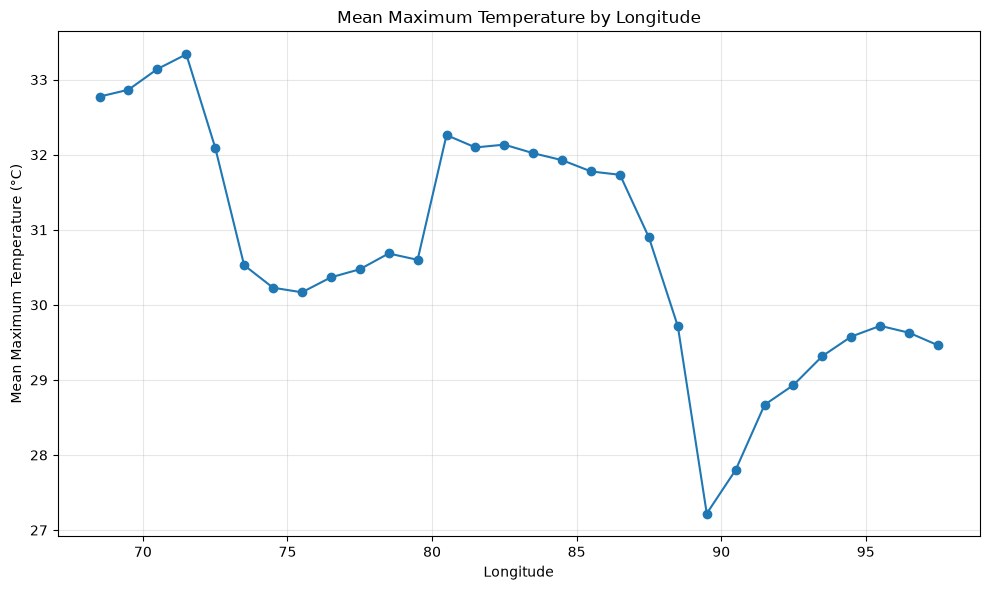

In [36]:
longitude_temperature = (
    df.groupby("longitude")["max_temperature"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    longitude_temperature["longitude"],
    longitude_temperature["max_temperature"],
    marker="o"
)

plt.title("Mean Maximum Temperature by Longitude")
plt.xlabel("Longitude")
plt.ylabel("Mean Maximum Temperature (°C)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Phase 3.5 → Extreme Heat & Heatwave Event Analysis

In [37]:
# Location-specific 95th percentile temperature

location_thresholds = (
    df.groupby(["latitude", "longitude"])["max_temperature"]
      .quantile(0.95)
      .reset_index(name="p95_temperature")
)

location_thresholds.head()

,latitude,longitude,p95_temperature
0,8.5,73.5,34.857802
1,8.5,76.5,33.911174
2,8.5,77.5,35.869999
3,8.5,78.5,36.248026
4,9.5,76.5,34.484395


In [38]:
df_extreme = df.merge(
    location_thresholds,
    on=["latitude", "longitude"],
    how="left"
)

df_extreme["extreme_heat"] = (
    df_extreme["max_temperature"] > df_extreme["p95_temperature"]
)

df_extreme.head()

,date,latitude,longitude,max_temperature,year,month,day,day_of_year,season,p95_temperature,extreme_heat
0,2010-01-01,8.5,73.5,32.869999,2010,1,1,1,Winter,34.857802,False
1,2010-01-01,8.5,76.5,31.040001,2010,1,1,1,Winter,33.911174,False
2,2010-01-01,8.5,77.5,32.040001,2010,1,1,1,Winter,35.869999,False
3,2010-01-01,8.5,78.5,31.110001,2010,1,1,1,Winter,36.248026,False
4,2010-01-01,9.5,76.5,31.270000,2010,1,1,1,Winter,34.484395,False


In [39]:
annual_extreme = (
    df_extreme.groupby(df_extreme["date"].dt.year)["extreme_heat"]
              .mean()
              .mul(100)
              .reset_index(name="extreme_heat_percentage")
)

annual_extreme

,date,extreme_heat_percentage
0,2010,8.141231
1,2011,2.527494
2,2012,5.230509
3,2013,4.638240
4,2014,5.433147
5,2015,4.170558
6,2016,7.019934
7,2017,5.764229
8,2018,4.382790
9,2019,7.569361


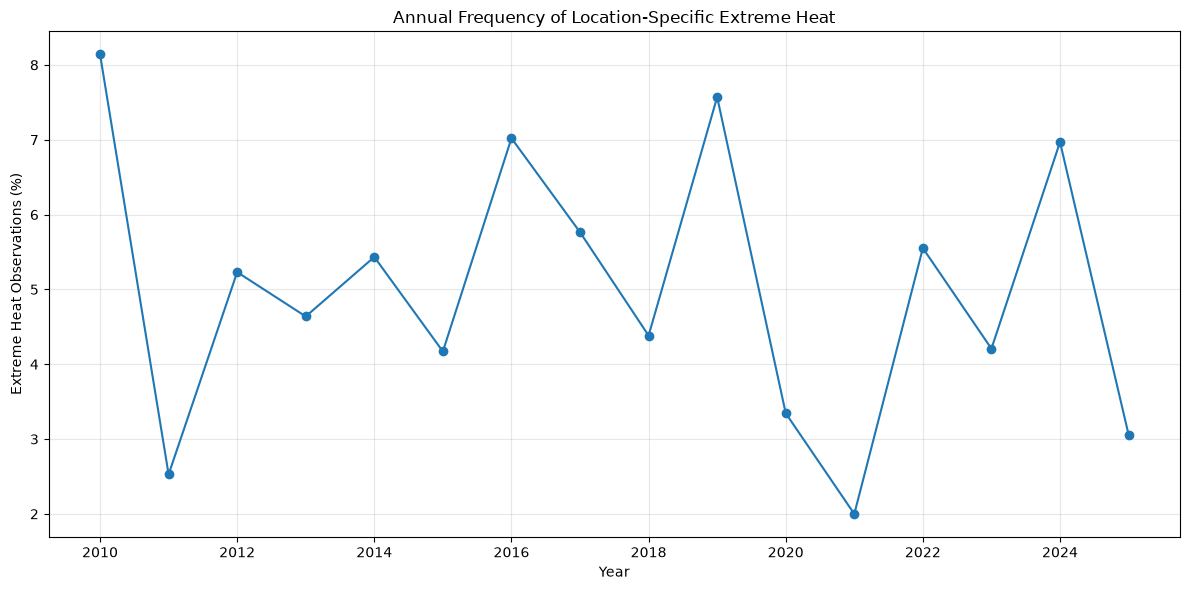

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(
    annual_extreme["date"],
    annual_extreme["extreme_heat_percentage"],
    marker="o"
)

plt.title("Annual Frequency of Location-Specific Extreme Heat")
plt.xlabel("Year")
plt.ylabel("Extreme Heat Observations (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
df_extreme = df_extreme.sort_values(
    ["latitude", "longitude", "date"]
).reset_index(drop=True)
group_cols = ["latitude", "longitude"]

df_extreme["date_diff"] = (
    df_extreme.groupby(group_cols)["date"]
              .diff()
              .dt.days
)

df_extreme["new_streak"] = (
    (df_extreme["date_diff"] != 1) |
    (df_extreme["date_diff"].isna()) |
    (~df_extreme["extreme_heat"])
)

df_extreme["streak_id"] = (
    df_extreme.groupby(group_cols)["new_streak"]
              .cumsum()
)
streaks = (
    df_extreme[df_extreme["extreme_heat"]]
    .groupby(group_cols + ["streak_id"])
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        duration=("date", "count")
    )
    .reset_index()
)

streaks.head()

,latitude,longitude,streak_id,start_date,end_date,duration
0,8.5,73.5,67,2010-03-09,2010-03-09,1
1,8.5,73.5,69,2010-03-12,2010-03-12,1
2,8.5,73.5,70,2010-03-14,2010-03-14,1
3,8.5,73.5,75,2010-03-20,2010-03-21,2
4,8.5,73.5,83,2010-03-30,2010-03-30,1


In [42]:
longest_streaks = (
    streaks.sort_values("duration", ascending=False)
           .head(20)
)

longest_streaks

,latitude,longitude,streak_id,start_date,end_date,duration
3037,14.5,75.5,2190,2016-03-18,2016-05-09,53
3111,14.5,76.5,2191,2016-03-17,2016-05-05,50
27944,32.5,79.5,5061,2024-05-13,2024-06-26,45
27859,32.5,78.5,5048,2024-05-13,2024-06-19,38
3187,14.5,77.5,2521,2017-03-25,2017-04-29,36
1256,11.5,72.5,2203,2016-04-10,2016-05-14,35
13160,23.5,84.5,818,2012-05-14,2012-06-15,33
68,8.5,73.5,4956,2024-03-12,2024-04-11,31
1759,12.5,74.5,2207,2016-04-10,2016-05-10,31
1350,11.5,75.5,2213,2016-04-10,2016-05-10,31


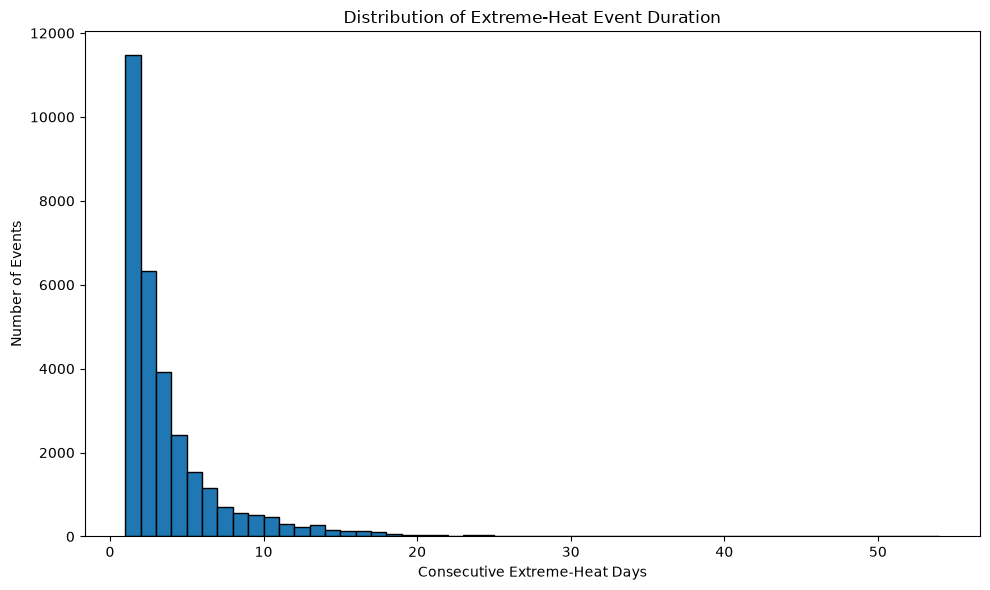

In [44]:
plt.figure(figsize=(10, 6))

plt.hist(
    streaks["duration"],
    bins=range(1, streaks["duration"].max() + 2),
    edgecolor="black"
)

plt.title("Distribution of Extreme-Heat Event Duration")
plt.xlabel("Consecutive Extreme-Heat Days")
plt.ylabel("Number of Events")

plt.tight_layout()
plt.show()

Phase 3.6 — Temperature Anomaly & Hotspot Analysis

In [45]:
df_anomaly = df.copy()

df_anomaly["month"] = df_anomaly["date"].dt.month

monthly_baseline = (
    df_anomaly
    .groupby(["latitude", "longitude", "month"])["max_temperature"]
    .mean()
    .reset_index(name="baseline_temperature")
)

monthly_baseline.head()

,latitude,longitude,month,baseline_temperature
0,8.5,73.5,1,32.677437
1,8.5,73.5,2,33.424065
2,8.5,73.5,3,34.140900
3,8.5,73.5,4,34.407108
4,8.5,73.5,5,33.188747


In [46]:
df_anomaly = df_anomaly.merge(
    monthly_baseline,
    on=["latitude", "longitude", "month"],
    how="left"
)

df_anomaly["temperature_anomaly"] = (
    df_anomaly["max_temperature"]
    - df_anomaly["baseline_temperature"]
)

df_anomaly.head()

,date,latitude,longitude,max_temperature,year,month,day,day_of_year,season,baseline_temperature,temperature_anomaly
0,2010-01-01,8.5,73.5,32.869999,2010,1,1,1,Winter,32.677437,0.192562
1,2010-01-01,8.5,76.5,31.040001,2010,1,1,1,Winter,31.037556,0.002445
2,2010-01-01,8.5,77.5,32.040001,2010,1,1,1,Winter,32.067989,-0.027988
3,2010-01-01,8.5,78.5,31.110001,2010,1,1,1,Winter,31.279467,-0.169466
4,2010-01-01,9.5,76.5,31.270000,2010,1,1,1,Winter,31.250628,0.019373


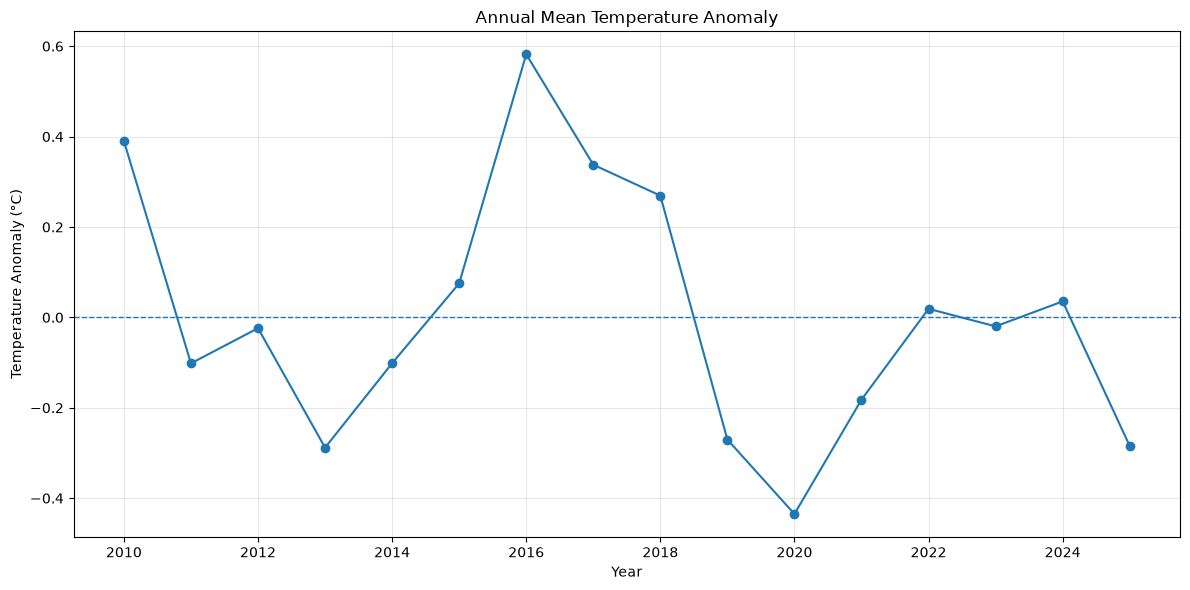

In [47]:
annual_anomaly = (
    df_anomaly
    .groupby(df_anomaly["date"].dt.year)["temperature_anomaly"]
    .mean()
    .reset_index(name="mean_anomaly")
)

plt.figure(figsize=(12, 6))

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.plot(
    annual_anomaly["date"],
    annual_anomaly["mean_anomaly"],
    marker="o"
)

plt.title("Annual Mean Temperature Anomaly")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
spatial_anomaly = (
    df_anomaly
    .groupby(["latitude", "longitude"])["temperature_anomaly"]
    .agg(
        mean_anomaly="mean",
        max_anomaly="max"
    )
    .reset_index()
)

In [49]:
top_anomaly_locations = (
    spatial_anomaly
    .sort_values("max_anomaly", ascending=False)
    .head(20)
)

top_anomaly_locations

,latitude,longitude,mean_anomaly,max_anomaly
350,35.5,79.5,-1.720218e-07,10.715221
354,36.5,75.5,2.210745e-07,10.470617
349,35.5,78.5,-1.855565e-07,10.377815
353,36.5,74.5,-2.287052e-07,10.314678
351,36.5,72.5,1.850835e-07,10.190823
337,34.5,73.5,2.737641e-07,10.172668
352,36.5,73.5,7.753019e-08,10.131153
211,25.5,78.5,-2.482099e-07,10.042545
344,35.5,73.5,-2.914369e-07,9.907288
346,35.5,75.5,2.650913e-08,9.860271


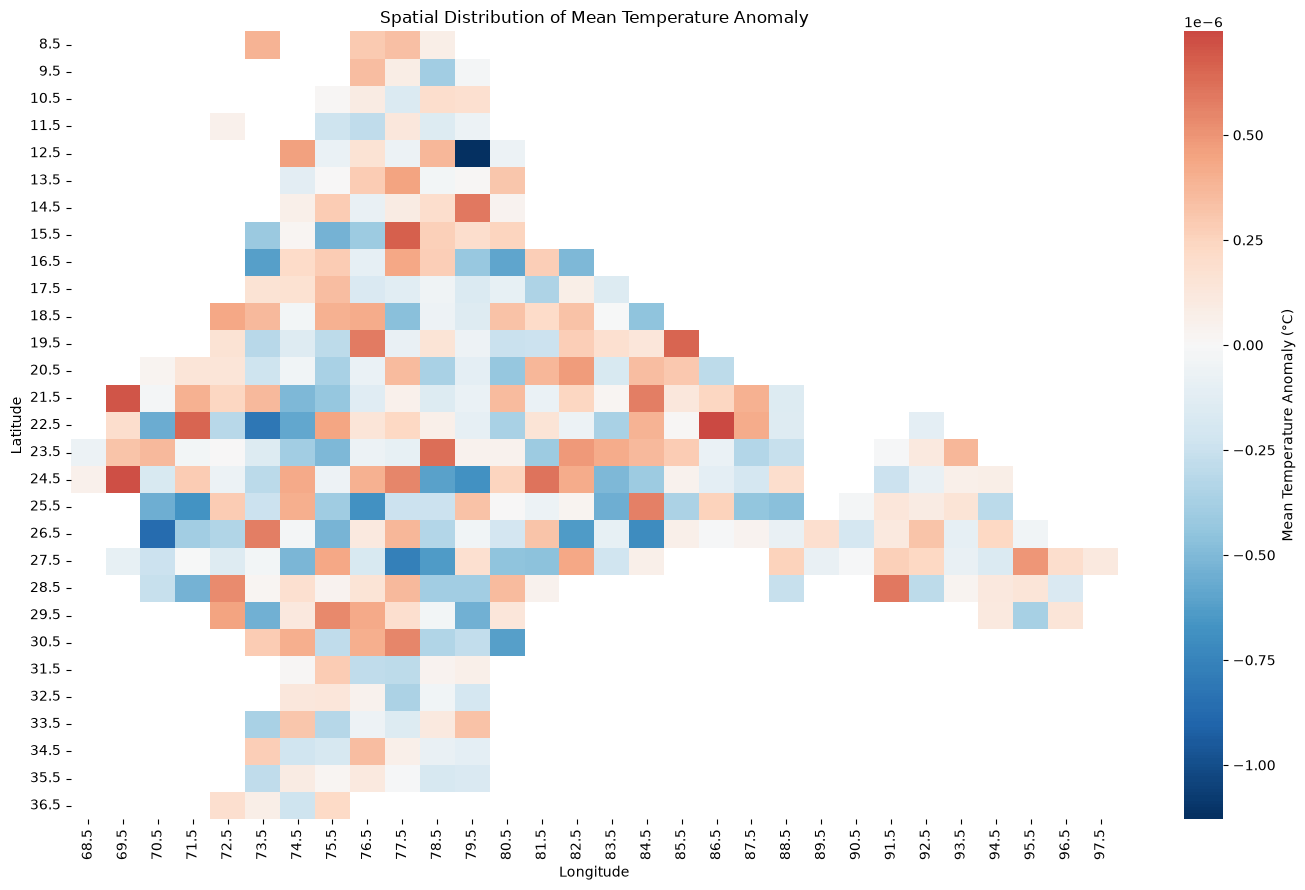

In [50]:
anomaly_pivot = spatial_anomaly.pivot(
    index="latitude",
    columns="longitude",
    values="mean_anomaly"
)

plt.figure(figsize=(14, 9))

sns.heatmap(
    anomaly_pivot,
    center=0,
    cmap="RdBu_r",
    annot=False,
    cbar_kws={"label": "Mean Temperature Anomaly (°C)"}
)

plt.title("Spatial Distribution of Mean Temperature Anomaly")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()